In [1]:
from Forecast.SimpleTransformerForecast import SimpleTransformerForecast
from Forecast.PatchTransformerForecast import PatchTransformerForecast
from Dataloaders.DataloaderECG import ECGDataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
import os
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Funcion para entrenar el modelo
def train_loop(model, train, val, optimizer, scheduler=None, patience=5, epochs=100, lossf=F.mse_loss):
    """_Bucle de entrenamiento_

    Args:
        model: red a entrenar
        optimizer: optimizador de pytorch, por ejemplo torch.optim.Adam
        train: datos de entrenamiento
        val: datos de validacion
        epochs: numero de epochs

    Returns:
        _type_: _description_
    """
    def epoch_loss(dataset):
        data_loss = 0.0
        for i, (lookback_data, horizon_data) in enumerate(dataset):
            inputs = lookback_data.to('cuda')
            y = horizon_data.to('cuda')
            outputs = model(inputs).squeeze()
            loss = lossf(y, outputs)
            data_loss += loss.item()  
        return data_loss / (i + 1)
    
    def early_stopping(val_loss, patience=5):
        if len(val_loss) > patience:
            if val_loss[-1] > np.mean(val_loss[-(patience+1):-1]):
                return True
    
    hist_loss = {'train': [], 'val': []}
    pbar = tqdm(range(epochs))
    for epoch in pbar:  # bucle para todos los epochs
        for i, (lookback_data, horizon_data) in enumerate(train):
            # obtenemos los datos y los subimos a la GPU
            inputs = lookback_data.to('cuda')
            y = horizon_data.to('cuda')

            # Reiniciamos los gradientes
            optimizer.zero_grad()

            # Aplicamos los datos al modelo
            outputs = model(inputs).squeeze()
            # Calculamos la perdida
            loss = lossf(y, outputs)

            # Hacemos el paso hacia atras
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        # Calculamos la perdida en el conjunto de entrenamiento y validacion
        with torch.no_grad():
            hist_loss['train'].append(epoch_loss(train))
            hist_loss['val'].append(epoch_loss(val))

        # Mostramos la perdida en el conjunto de entrenamiento y validacion
        pbar.set_postfix({'train': hist_loss['train'][-1], 'val': hist_loss['val'][-1]})

        # Si la perdida en el conjunto de validacion no disminuye, paramos el entrenamiento
        if early_stopping(hist_loss['val'], patience):
            break
            
    return hist_loss 

In [17]:
lookback = 160
horizon = 20
batch_size = 512
stride = 100

In [18]:
train = ECGDataset(dir='../Preprocess/PTBXL',
                   dataset='train',
                   nsamples=2500,
                   channel=0,
                   lookback=lookback,
                   horizon=horizon,
                   stride=stride)
val = ECGDataset(dir='../Preprocess/PTBXL',
                   dataset='validation',
                   nsamples=50,
                   channel=0,
                   lookback=lookback,
                   horizon=horizon,
                   stride=stride)
train = DataLoader(train, batch_size=batch_size, shuffle=True)
val = DataLoader(val, batch_size=batch_size, shuffle=False)


Loading data from ../Preprocess/PTBXL
train
X_train shape is (22500, 8, 160)
y_train shape is (22500, 20)
NORM=None
Loading data from ../Preprocess/PTBXL
validation
X_train shape is (450, 8, 160)
y_train shape is (450, 20)
NORM=None


In [5]:
# model = SimpleTransformerForecast(lookback=lookback,
#                                   horizon=horizon,
#                                   input_dim=8,
#                                   target_dim=1,
#                                   d_model=16,
#                                   n_heads=2,
#                                   num_layers=6, dropout=0).to('cuda')
# model.compile()

In [22]:
model = PatchTransformerForecast(lookback=lookback,
                                horizon=horizon,
                                input_dim=8,
                                target_dim=1,
                                d_model=32,
                                n_heads=8,
                                num_layers=6, dropout=0, patch_len=16).to('cuda')

In [23]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.9)

In [8]:
# # Testing the model with random input
# random_input = torch.randn(32, 8, 120).to('cuda')
# model.to('cuda')
# model(random_input).shape

In [ ]:
hist_loss = train_loop(model, train, val, optimizer, scheduler, epochs=1000, patience=50)

  0%|          | 0/1000 [00:00<?, ?it/s]

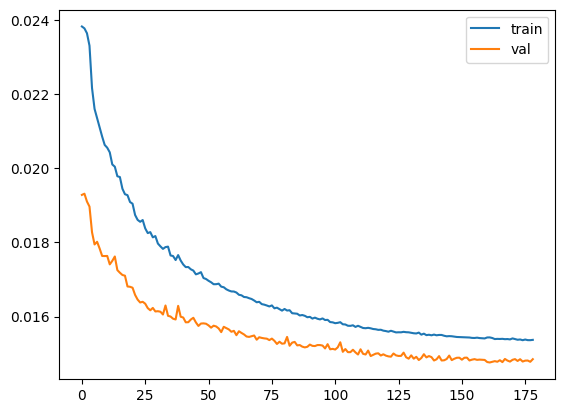

In [10]:
plt.plot(hist_loss['train'], label='train')
plt.plot(hist_loss['val'], label='val')
plt.legend()

In [11]:
print(scheduler.get_last_lr())

[2.503155504993244e-06]


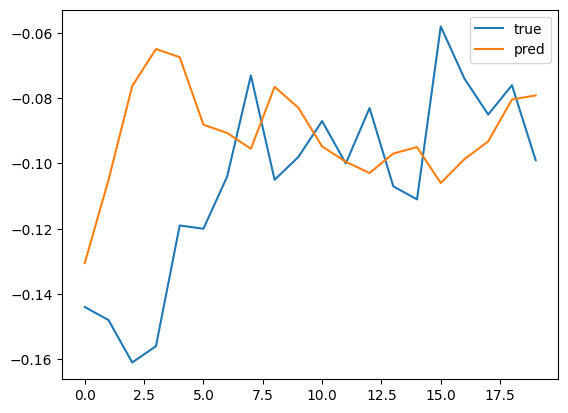

In [12]:
X, y = train.dataset[0]


pred = model(torch.tensor(X).unsqueeze(0).to('cuda')).squeeze().cpu().detach().numpy()
plt.plot(y, label='true')
plt.plot(pred, label='pred')
plt.legend()

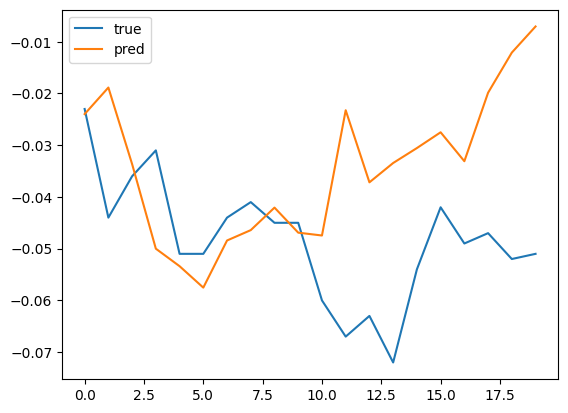

In [13]:
X, y = val.dataset[0]


pred = model(torch.tensor(X).unsqueeze(0).to('cuda')).squeeze().cpu().detach().numpy()
plt.plot(y, label='true')
plt.plot(pred, label='pred')
plt.legend()